In [12]:
# RELATION BETWEEN SHAPE FEATURES AND CATEGORICAL FEATURES -> KRUSKAL-WALLIS TEST
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


main_folder_path = r"E:\DATA_Myelomy"

all_patients = []
for folder_name in os.listdir(main_folder_path):
    patient_folder_path = os.path.join(main_folder_path, folder_name)

    csv_files = glob.glob(os.path.join(patient_folder_path, "*individual_lesion_features*.csv"))
    csv_path = csv_files[0]  # choose first one (does not matter, shape features are same for every image)

    df = pd.read_csv(csv_path).filter(like="shape")

    shape_features_stats = {"patient": folder_name}
    for col in df.columns:
        x = df[col].dropna()

        shape_features_stats[f"{col}_mean"]   = x.mean()
        shape_features_stats[f"{col}_median"] = x.median()
        shape_features_stats[f"{col}_std"]    = x.std()
        shape_features_stats[f"{col}_var"]    = x.var()
        shape_features_stats[f"{col}_cv"]     = x.std() / x.mean()     # coefficient of variation
        shape_features_stats[f"{col}_range"]  = x.max() - x.min()
        shape_features_stats[f"{col}_min"]    = x.min()
        shape_features_stats[f"{col}_max"]    = x.max()

        from scipy.stats import skew, kurtosis
        shape_features_stats[f"{col}_skewness"] = skew(x)
        shape_features_stats[f"{col}_kurtosis"] = kurtosis(x)

        shape_features_stats[f"{col}_percentile10"] = x.quantile(0.10)
        shape_features_stats[f"{col}_percentile25"] = x.quantile(0.25)
        shape_features_stats[f"{col}_percentile75"] = x.quantile(0.75)
        shape_features_stats[f"{col}_percentile90"] = x.quantile(0.90)
        shape_features_stats[f"{col}_IQR"] = x.quantile(0.75) - x.quantile(0.25)  # InterQuartileRange (P75-P25)

        hist, _ = np.histogram(x, bins=20)
        hist = hist / hist.sum()
        hist = hist[hist > 0]

        from scipy.stats import entropy
        shape_features_stats[f"{col}_entropy"] = entropy(hist)

    all_patients.append(shape_features_stats)
df_final = pd.DataFrame(all_patients)


clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
merged_df = pd.merge(df_final, clinical_df, left_on='patient', right_on='Patient ID')

categoric_features_clinical = ["ISS classification", "M-protein type", "Light chain type"]
numeric_features_image = df_final.select_dtypes(include=['number']).columns

for clinical_col in categoric_features_clinical:

        if clinical_col not in merged_df.columns:
            continue

        kruskal_wallis = {}
        for radiomic_col in numeric_features_image:

            data_subset = merged_df[[radiomic_col, clinical_col]].dropna()

            groups = [group[radiomic_col].dropna().values for name, group in merged_df.groupby(clinical_col)]

            if len(groups) > 1:
                from scipy.stats import kruskal
                stat, p_value = kruskal(*groups)

                if p_value < 0.05:
                    kruskal_wallis[radiomic_col] = {'stat': stat, 'p_value': p_value}

        if kruskal_wallis:
            kruskal_wallis_df = pd.DataFrame(kruskal_wallis).T
            kruskal_wallis_df = kruskal_wallis_df.sort_values(by='stat', ascending=False)
            print(f"Results for {clinical_col}:")
            print(kruskal_wallis_df.head())
        else:
            print(f"No significant correlations for {clinical_col}")
        print("-" * 50)

Results for ISS classification:
                                           stat   p_value
original_shape_Flatness_mean          14.265137  0.000799
original_shape_Flatness_percentile75  13.662323  0.001080
original_shape_Flatness_median        13.100096  0.001430
original_shape_Elongation_median      11.588060  0.003046
original_shape_Elongation_mean        11.188244  0.003720
--------------------------------------------------
Results for M-protein type:
                                                        stat   p_value
original_shape_SurfaceVolumeRatio_percentile10      9.216296  0.009970
original_shape_Maximum2DDiameterColumn_percenti...  8.850024  0.011974
original_shape_MinorAxisLength_cv                   7.893155  0.019321
original_shape_Elongation_IQR                       7.762492  0.020625
original_shape_Sphericity_percentile75              7.504066  0.023470
--------------------------------------------------
Results for Light chain type:
                                  

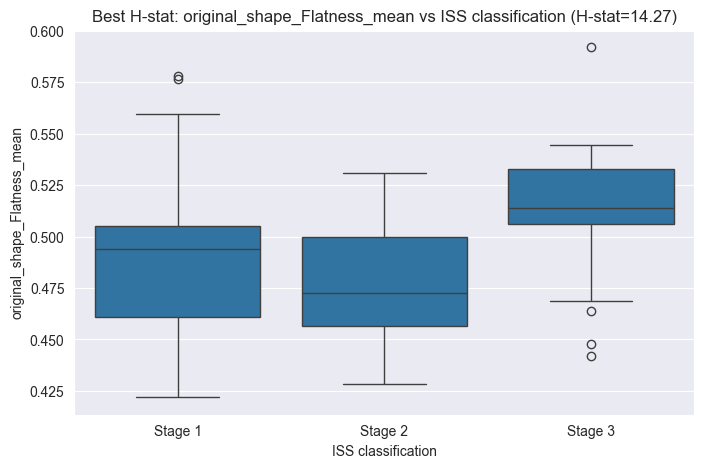

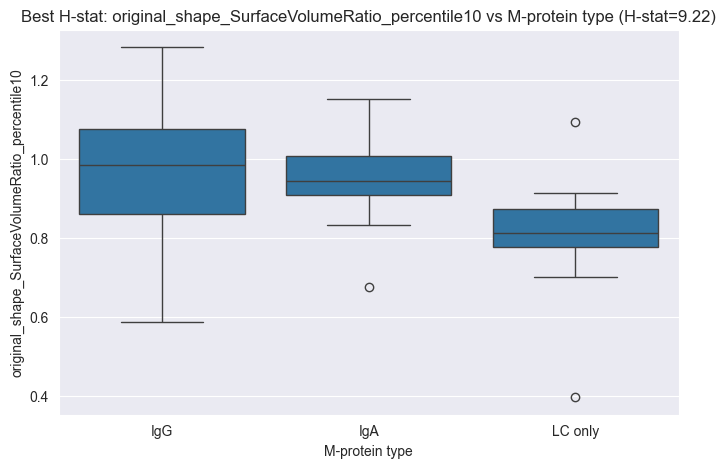

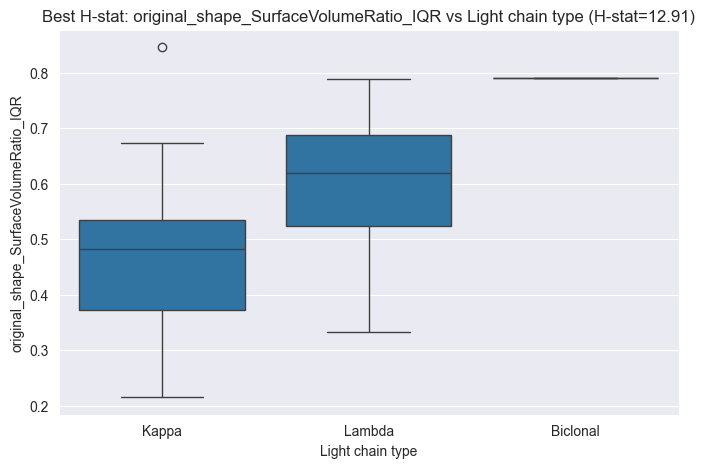

In [13]:
for clinical_col in categoric_features_clinical:
        if clinical_col not in merged_df.columns:
            continue

        best_radiomic = None
        final_stat_val = 0

        for radiomic_col in numeric_features_image:
            subset = merged_df[[radiomic_col, clinical_col]].dropna()

            # Use subset for the group calculation to ensure alignment
            groups = [group[radiomic_col].values for name, group in subset.groupby(clinical_col)]

            # Need at least two groups and data in them for Kruskal
            if len(groups) > 1:
                stat, p_value = kruskal(*groups)

                if p_value < 0.05 and stat > final_stat_val:
                    final_stat_val = stat # Update the statistic tracking
                    best_radiomic = radiomic_col

        # 2. Plotting the champion
        if best_radiomic:
            plt.figure(figsize=(8, 5))
            # FIX: Use merged_df, and the correct variable names
            sns.boxplot(data=merged_df, x=clinical_col, y=best_radiomic)

            # FIX: Changed 'Best Corr' to 'Best H-stat' to match Kruskal-Wallis output
            plt.title(f"Best H-stat: {best_radiomic} vs {clinical_col} (H-stat={final_stat_val:.2f})")
            plt.show()
            print()

In [14]:
# RELATION BETWEEN SHAPE FEATURES AND CATEGORICAL FEATURES -> SPEARMAN TEST
numeric_features_clinical = clinical_df.select_dtypes(include=['number']).columns
for clinical_col in numeric_features_clinical:

        if clinical_col not in merged_df.columns:
            continue

        spearman_corr = {}
        for radiomic_col in numeric_features_image:

            data_subset = merged_df[[radiomic_col, clinical_col]].dropna()

            if len(data_subset) > 1: # Spearman needs at least 2 points
                from scipy.stats import spearmanr
                corr, p_value = spearmanr(data_subset[radiomic_col], data_subset[clinical_col], nan_policy='omit')

                if p_value < 0.05:
                    spearman_corr[radiomic_col] = {'corr': corr, 'p_value': p_value}

        if spearman_corr:
            spearman_df = pd.DataFrame(spearman_corr).T
            spearman_df = spearman_df.sort_values(by='corr', ascending=False)
            print(f"Results for {clinical_col}:")
            print(spearman_df.head(3))
            print(spearman_df.tail(3))
        else:
            print(f"No significant correlations for {clinical_col}")
        print("-" * 50)

Results for Serum M-protein quantity (g/l):
                                              corr   p_value
original_shape_MajorAxisLength_entropy    0.349891  0.006136
original_shape_Maximum3DDiameter_entropy  0.297896  0.020794
original_shape_MinorAxisLength_entropy    0.274499  0.033797
                                            corr   p_value
original_shape_MinorAxisLength_entropy  0.274499  0.033797
original_shape_Sphericity_skewness      0.268963  0.037708
original_shape_Elongation_IQR           0.257473  0.047028
--------------------------------------------------
Results for Serum kappa FLC quantity (mg/l:
                                                        corr   p_value
original_shape_MinorAxisLength_percentile10         0.283603  0.025501
original_shape_Maximum2DDiameterSlice_percentile25  0.263383  0.038607
                                                        corr   p_value
original_shape_MinorAxisLength_percentile10         0.283603  0.025501
original_shape_Maximum2DDi

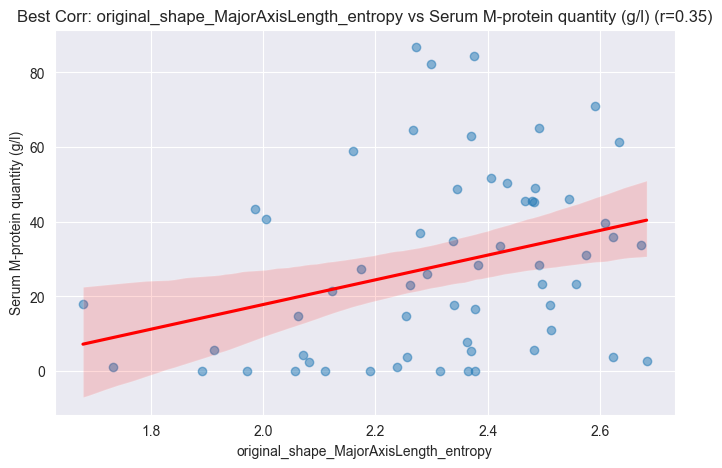

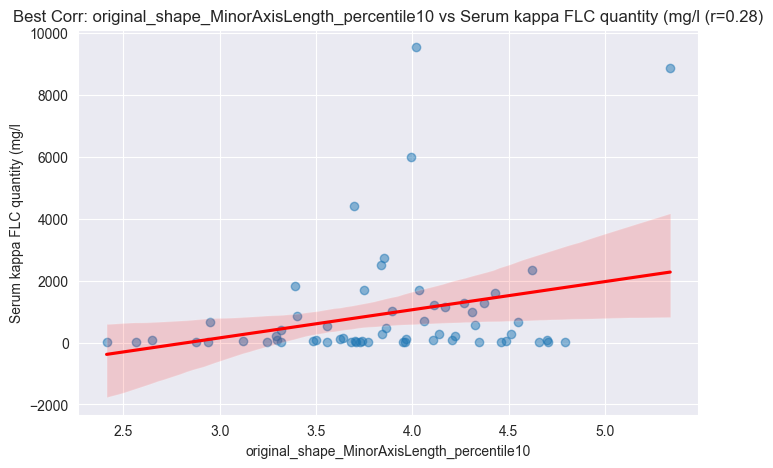

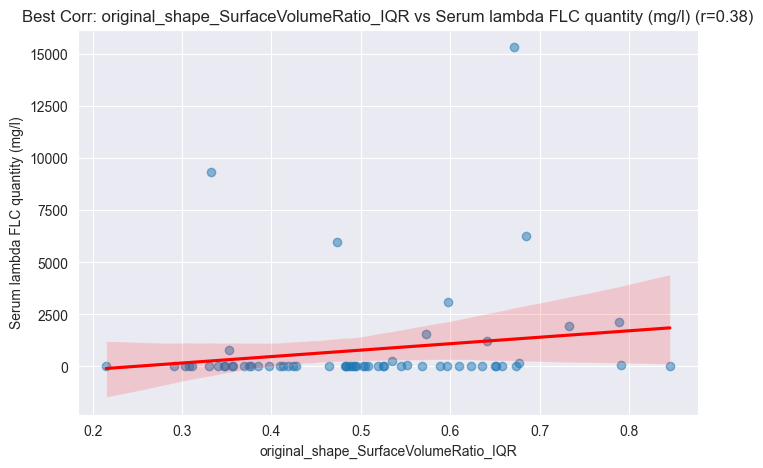

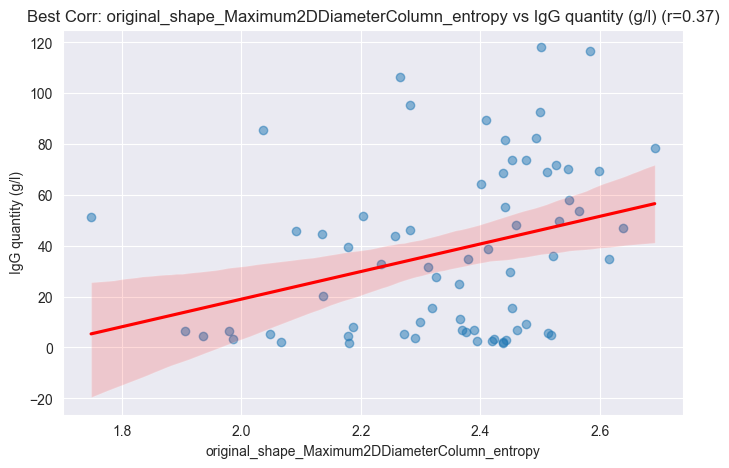

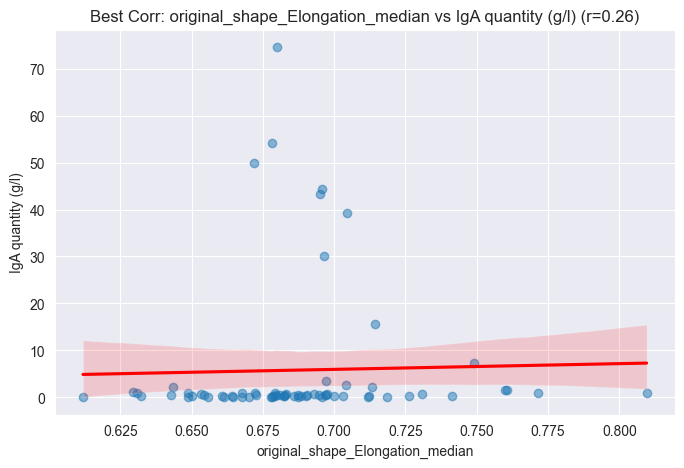

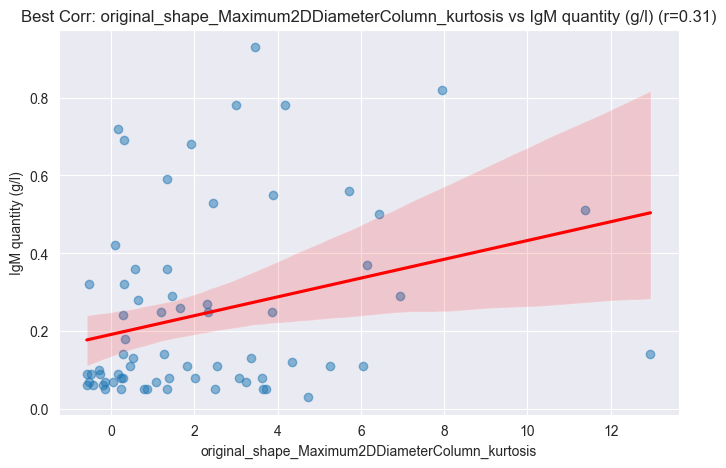

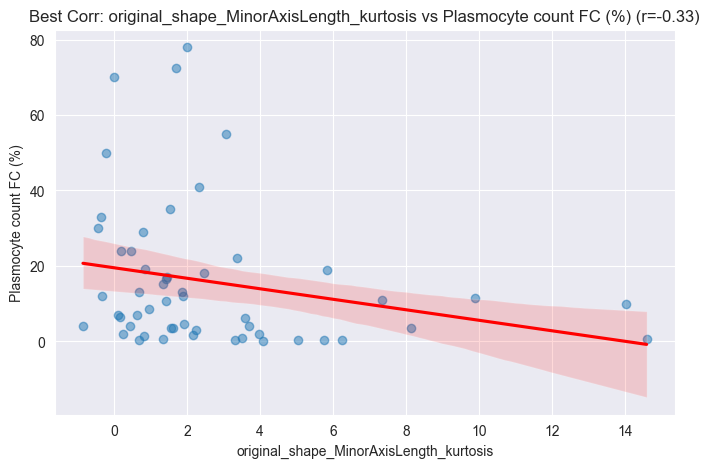

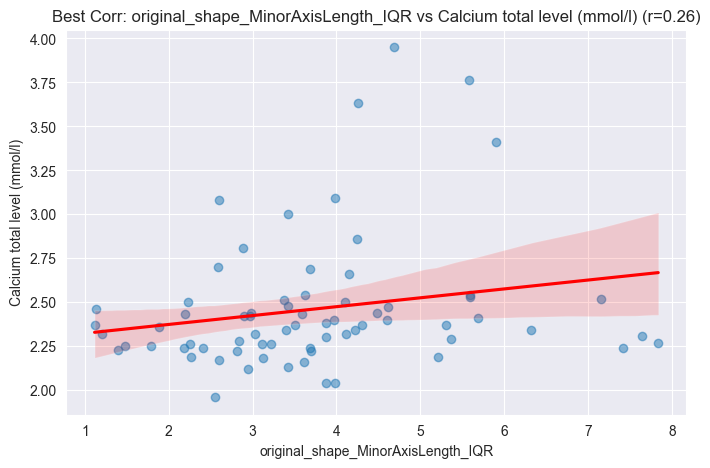

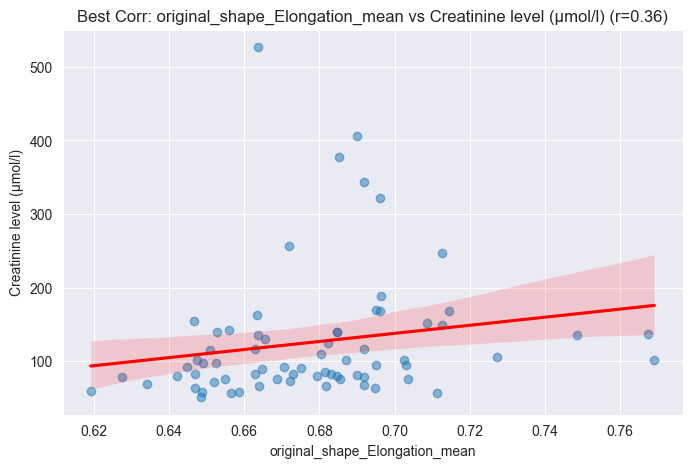

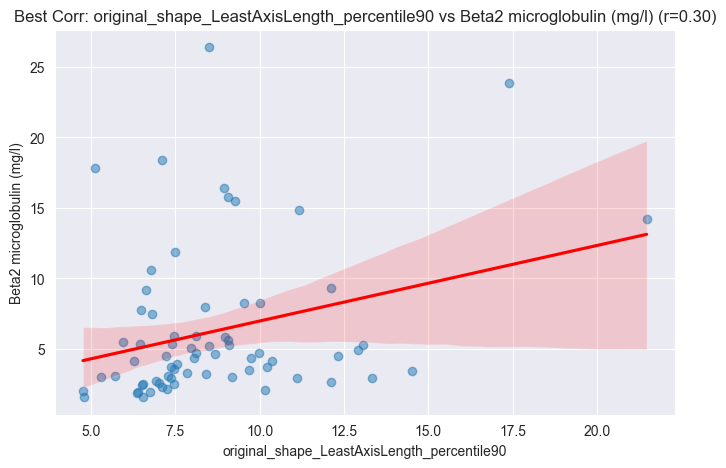

In [15]:
for clinical_col in numeric_features_clinical:
        if clinical_col not in merged_df.columns:
            continue

        best_radiomic = None
        max_abs_corr = 0
        final_corr_val = 0

        for radiomic_col in numeric_features_image:
            subset = merged_df[[radiomic_col, clinical_col]].dropna()

            if len(subset) > 1:
                corr, p_value = spearmanr(subset[radiomic_col], subset[clinical_col], nan_policy='omit')

                if p_value < 0.05 and abs(corr) > max_abs_corr:
                    max_abs_corr = abs(corr)
                    final_corr_val = corr
                    best_radiomic = radiomic_col

        # 2. Plotting the champion
        if best_radiomic:
            plt.figure(figsize=(8, 5))
            sns.regplot(data=merged_df, x=best_radiomic, y=clinical_col,
                        scatter_kws={'alpha':0.5}, line_kws={'color': 'red'})

            plt.title(f"Best Corr: {best_radiomic} vs {clinical_col} (r={final_corr_val:.2f})")
            plt.xlabel(best_radiomic)
            plt.ylabel(clinical_col)
            plt.show()
            print()